In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import plot_tree


In [2]:
df = pd.read_csv("C:/Users/vimal/Downloads/heart_disease.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63.0,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,FALSE,2.3,downsloping,fixed defect,0.0
1,41.0,Male,atypical angina,135.0,203.0,False,normal,132.0,FALSE,0.0,flat,fixed defect,0.0
2,57.0,Male,asymptomatic,140.0,192.0,False,normal,148.0,FALSE,0.4,flat,fixed defect,0.0
3,52.0,Male,typical angina,118.0,186.0,False,lv hypertrophy,190.0,FALSE,0.0,flat,fixed defect,0.0
4,57.0,Male,asymptomatic,110.0,201.0,False,normal,126.0,TRUE,1.5,flat,fixed defect,0.0


In [3]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    float64
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    float64
 4   chol      908 non-null    float64
 5   fbs       908 non-null    object 
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    float64
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    float64
dtypes: float64(6), object(7)
memory usage: 101.6+ KB


In [5]:
df.isnull().sum()

age          91
sex          91
cp           91
trestbps     91
chol         91
fbs          91
restecg      91
thalch       91
exang        91
oldpeak     153
slope        91
thal         91
num          91
dtype: int64

In [6]:
df = df.fillna(df.mode().iloc[0])

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

## Handle missing values

In [8]:
df = df.fillna(df.mode().iloc[0])

## Feature Engineering

In [9]:
# Convert categorical to numeric
df['sex'] = df['sex'].map({'Male':1, 'Female':0})

# One-hot encoding
df = pd.get_dummies(df, drop_first=True)

## Split data

In [10]:
X = df.drop('num', axis=1)
y = df['num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model building

In [11]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier()

In [12]:
y_pred = model.predict(X_test)

In [13]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.505
              precision    recall  f1-score   support

         0.0       0.70      0.75      0.72        96
         1.0       0.36      0.30      0.33        53
         2.0       0.18      0.28      0.22        18
         3.0       0.30      0.25      0.27        24
         4.0       0.40      0.22      0.29         9

    accuracy                           0.51       200
   macro avg       0.39      0.36      0.37       200
weighted avg       0.50      0.51      0.50       200



## Confusion Matrix

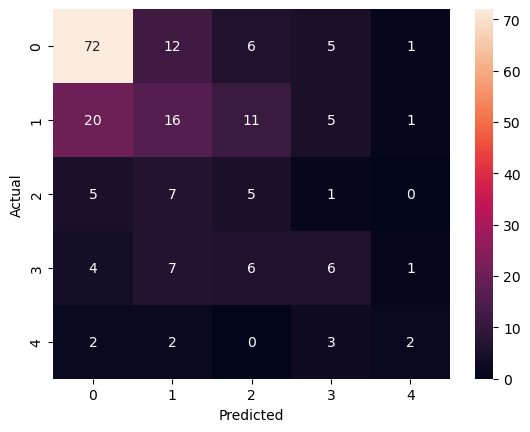

In [14]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Hyperparameter Tuning

In [15]:
param_grid = {
    'max_depth': [3,5,7,10],
    'min_samples_split': [2,5,10]
}

grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': 7, 'min_samples_split': 10}


In [16]:
y_pred = model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Tuned Accuracy: 0.575
              precision    recall  f1-score   support

         0.0       0.69      0.80      0.74        96
         1.0       0.48      0.58      0.53        53
         2.0       0.19      0.17      0.18        18
         3.0       0.50      0.17      0.25        24
         4.0       0.00      0.00      0.00         9

    accuracy                           0.57       200
   macro avg       0.37      0.34      0.34       200
weighted avg       0.54      0.57      0.54       200



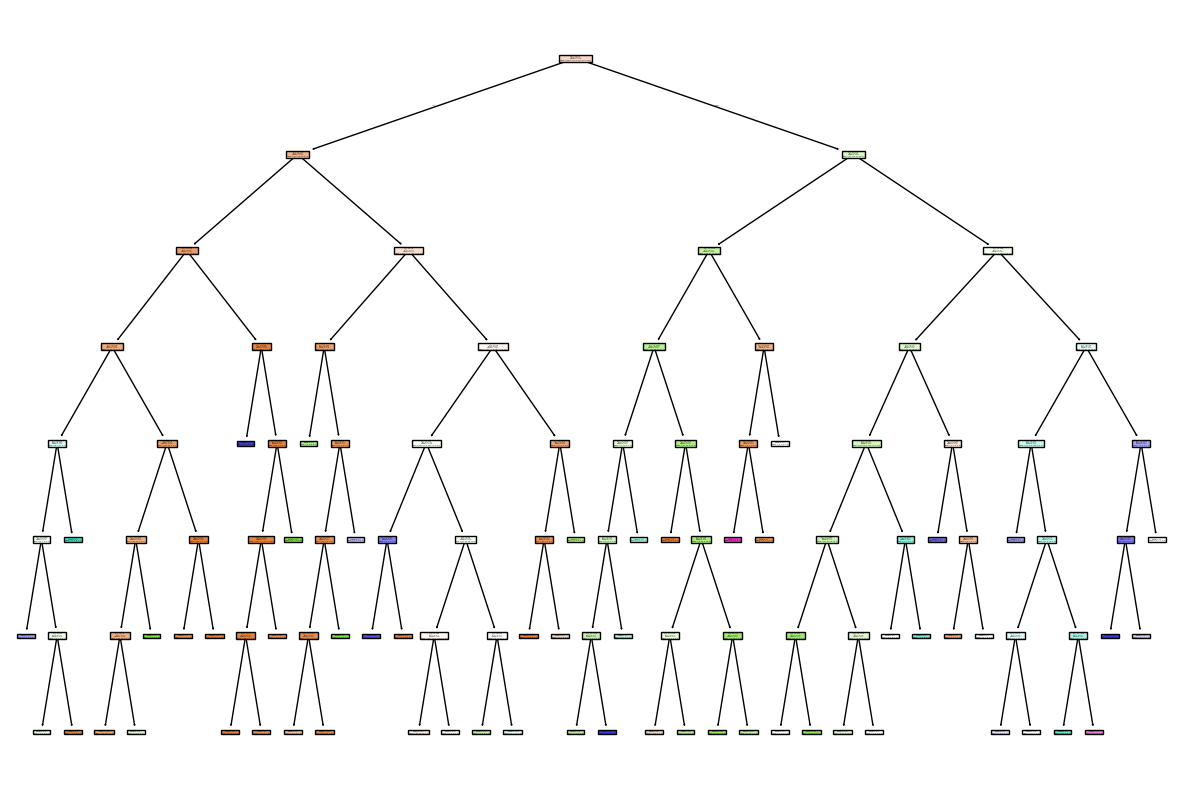

In [17]:
plt.figure(figsize=(15,10))
plot_tree(model, filled=True)
plt.show()

## Interview Questions

Q1. What is Decision Tree?
A Decision Tree is a supervised machine learning algorithm used for classification and regression.

Q2. What is overfitting?
Overfitting occurs when the model performs well on training data but poorly on new data.

Q3. What is entropy?
Entropy measures randomness or impurity in data.

Q4. What is Gini Index?
Gini index is used to measure impurity and select best split.

Q5. What is pruning?
Pruning removes unnecessary branches to avoid overfitting.